In [5]:
# DIABETES (SUGAR) PREDICTION USING LOGISTIC REGRESSION

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [6]:
# Create synthetic dataset
data = {
    'Glucose_Level': [80, 85, 90, 95, 100, 120, 140, 160, 180, 200],
    
    'BMI': [18, 19, 20, 21, 22, 25, 27, 30, 32, np.nan],
    
    'Diabetes': ['No', 'No', 'No', 'No', 'No',
                 'Yes', 'Yes', 'Yes', 'Yes', 'Yes']
}

records = pd.DataFrame(data)


In [7]:
# Display first 5 rows
print(records.head())

   Glucose_Level   BMI Diabetes
0             80  18.0       No
1             85  19.0       No
2             90  20.0       No
3             95  21.0       No
4            100  22.0       No


In [8]:
# Display last 5 rows
print(records.tail())

   Glucose_Level   BMI Diabetes
5            120  25.0      Yes
6            140  27.0      Yes
7            160  30.0      Yes
8            180  32.0      Yes
9            200   NaN      Yes


In [9]:
# Dataset summary
print(records.describe())



       Glucose_Level        BMI
count      10.000000   9.000000
mean      125.000000  23.777778
std        42.817442   4.994441
min        80.000000  18.000000
25%        91.250000  20.000000
50%       110.000000  22.000000
75%       155.000000  27.000000
max       200.000000  32.000000


In [10]:
# Dataset information
print(records.info())

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Glucose_Level  10 non-null     int64  
 1   BMI            9 non-null      float64
 2   Diabetes       10 non-null     str    
dtypes: float64(1), int64(1), str(1)
memory usage: 372.0 bytes
None


In [11]:
# Check missing values
print(records.isnull().sum())


Glucose_Level    0
BMI              1
Diabetes         0
dtype: int64


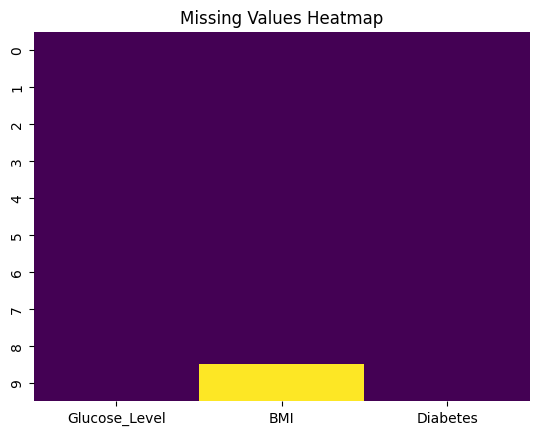

In [12]:
# Heatmap for missing values
sns.heatmap(records.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

In [13]:
# Fill missing values with mean
records['BMI'] = records['BMI'].fillna(
    records['BMI'].mean()
)

In [14]:
# Convert target variable into binary
records['Diabetes'] = records['Diabetes'].map({
    'Yes': 1,
    'No': 0
})

In [15]:
# Display updated dataset
print(records.head())

   Glucose_Level   BMI  Diabetes
0             80  18.0         0
1             85  19.0         0
2             90  20.0         0
3             95  21.0         0
4            100  22.0         0


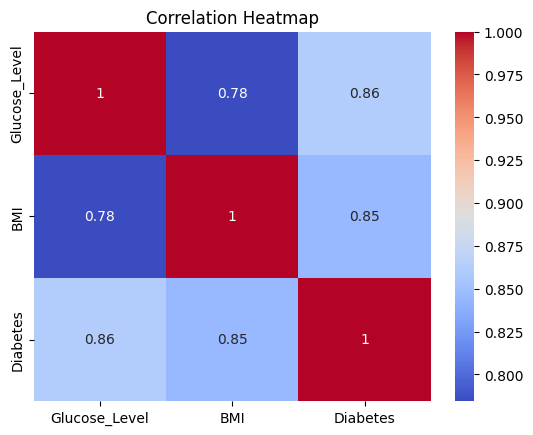

In [16]:
# Correlation heatmap
sns.heatmap(records.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [17]:
# Features and target variable
X = records[['Glucose_Level', 'BMI']]
y = records['Diabetes']

In [18]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [19]:
# Display training data
print(X_train.head())

   Glucose_Level        BMI
5            120  25.000000
0             80  18.000000
7            160  30.000000
2             90  20.000000
9            200  23.777778


In [20]:
# Display testing data
print(X_test.head())


   Glucose_Level   BMI
8            180  32.0
1             85  19.0


In [21]:

# Logistic Regression model
model = LogisticRegression()


In [22]:
# Train model
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [23]:
# Predictions
y_pred = model.predict(X_test)

In [24]:

# Confusion matrix and classification report
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred))

print(classification_report(y_test, y_pred))

[[1 0]
 [0 1]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



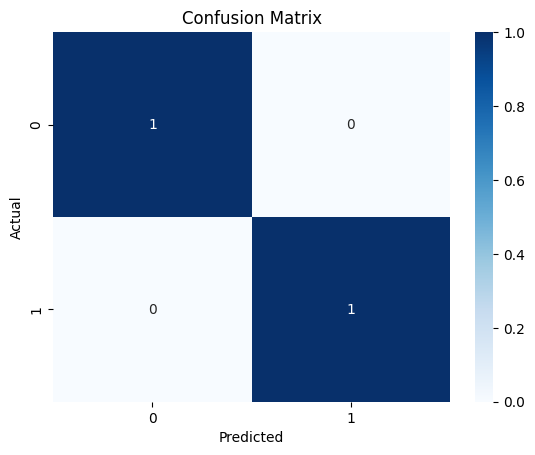

In [25]:
# Heatmap for confusion matrix
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [26]:
# Predict new patient data
new_patient = pd.DataFrame({
    'Glucose_Level': [150],
    'BMI': [29]
})

prediction = model.predict(new_patient)

if prediction[0] == 1:
    print("Diabetes Detected")
else:
    print("No Diabetes")

Diabetes Detected


In [27]:

# Save model
import joblib

joblib.dump(model, 'diabetes_prediction_model.pkl')

print("Model saved successfully!")

Model saved successfully!
